In [1]:
import os 


#Pasta com scedec
PASTA_RAIZ = r'C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds'

PASTA_WAVEFORMS = os.path.join(PASTA_RAIZ, "event_waveforms")
PASTA_XML       = os.path.join(PASTA_RAIZ, "FDSNstationXML")

# Onde salvar os resultados deste projeto
PASTA_PROJETO   = r"C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts"

# Canal preferido para análise
CANAL_ALVO = "BHZ"
os.makedirs(PASTA_PROJETO, exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "data", "processed"), exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "data", "windows"), exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "models"), exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "results"), exist_ok=True)
os.makedirs(os.path.join(PASTA_PROJETO, "figures"), exist_ok=True)

print("✅ Caminhos configurados")
print(f"   Waveforms : {PASTA_WAVEFORMS}")
print(f"   XMLs      : {PASTA_XML}")
print(f"   Projeto   : {PASTA_PROJETO}")

# Verificando se as pastas existem
for nome, pasta in [("Waveforms", PASTA_WAVEFORMS), ("XMLs", PASTA_XML)]:
    if os.path.exists(pasta):
        print(f"   ✅ {nome}: pasta encontrada")
    else:
        print(f"   ❌ {nome}: PASTA NÃO ENCONTRADA — verifique o caminho")

✅ Caminhos configurados
   Waveforms : C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds\event_waveforms
   XMLs      : C:\Users\vish8\OneDrive\Documentos\TCC\data\scedc-pds\FDSNstationXML
   Projeto   : C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts
   ✅ Waveforms: pasta encontrada
   ✅ XMLs: pasta encontrada


In [2]:
#Varrendos as pastas para verificar arquivos
import os
from pathlib import Path

# Encontrar todos os arquivos .ms recursivamente
arquivos_ms = []
for root, dirs, files in os.walk(PASTA_WAVEFORMS):
    for f in files:
        if f.endswith('.ms') or f.endswith('.mseed') or f.endswith('.miniseed'):
            arquivos_ms.append(os.path.join(root, f))

# Encontrar todos os XMLs
arquivos_xml = []
for root, dirs, files in os.walk(PASTA_XML):
    for f in files:
        if f.endswith('.xml') or f.endswith('.XML'):
            arquivos_xml.append(os.path.join(root, f))

print(f"📦 Arquivos .ms encontrados  : {len(arquivos_ms)}")
print(f"📋 Arquivos XML encontrados  : {len(arquivos_xml)}")
print()

if len(arquivos_ms) == 0:
    print("❌ ATENÇÃO: Nenhum arquivo .ms encontrado!")
    print("   Verifique se PASTA_WAVEFORMS está correto")
    print(f"   Pasta atual: {PASTA_WAVEFORMS}")
else:
    print("Primeiros 10 arquivos .ms:")
    for f in arquivos_ms[:10]:
        tamanho_kb = os.path.getsize(f) / 1024
        print(f"   {os.path.basename(f):30s}  ({tamanho_kb:.1f} KB)")
    if len(arquivos_ms) > 10:
        print(f"   ... e mais {len(arquivos_ms)-10} arquivos")

print()
print("XMLs disponíveis:")
for f in arquivos_xml[:10]:
    print(f"   {os.path.basename(f)}")
if len(arquivos_xml) > 10:
    print(f"   ... e mais {len(arquivos_xml)-10} XMLs")


📦 Arquivos .ms encontrados  : 31
📋 Arquivos XML encontrados  : 53

Primeiros 10 arquivos .ms:
   37509232.ms                     (14295.5 KB)
   37509240.ms                     (19753.0 KB)
   37509248.ms                     (8890.0 KB)
   37509256.ms                     (6613.5 KB)
   37509264.ms                     (19970.5 KB)
   37509272.ms                     (18909.5 KB)
   37509288.ms                     (1464.0 KB)
   37509296.ms                     (4731.5 KB)
   37509304.ms                     (3307.5 KB)
   37509312.ms                     (12999.5 KB)
   ... e mais 21 arquivos

XMLs disponíveis:
   AZ.BZN.xml
   C2-2CI.PASC.xml
   CI.PASC.xml
   CI_ABL.xml
   CI_ACP.xml
   CI_ADL.xml
   CI_ADO.xml
   CI_AGA.xml
   CI_AGM.xml
   CI_AGO.xml
   ... e mais 43 XMLs


In [3]:
#Inspecionando  um arquivo .ms e um XML
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

if len(arquivos_ms) ==0:
    print("❌ Nenhum arquivo .ms para inspecionar")
else:
    #Abrindo o primeiro arquivo
    arquivo_teste = arquivos_ms[0]
    print(f'Abrindo {os.path.basename(arquivo_teste)}')
    print("-" *60)
    st = read(arquivo_teste)
    print(f'Stream : {st}')
    print("-" *60)
    #Informações do trace
    for tr in st:
        print(f'Trace ID: {tr.id}')
        print(f'  Canal   : {tr.stats.channel}')
        print(f'  Estação  : {tr.stats.station}')
        print(f'  Rede     : {tr.stats.network}')
        print(f'  Local     : {tr.stats.location}')
        print(f'  Início    : {tr.stats.starttime}')
        print(f'  Tamanho   : {len(tr.data)} amostras')
        print(f'  Taxa      : {tr.stats.sampling_rate} Hz')
        print("-" *60)
    

Abrindo 37509232.ms
------------------------------------------------------------
Stream : 1329 Trace(s) in Stream:

AZ.BZN..BHE | 2016-01-01T00:12:56.594500Z - 2016-01-01T00:13:59.569500Z | 40.0 Hz, 2520 samples
...
(1327 other traces)
...
WR.PEC..HNZ | 2016-01-01T00:12:48.375000Z - 2016-01-01T00:13:50.370000Z | 200.0 Hz, 12400 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
------------------------------------------------------------
Trace ID: AZ.BZN..BHE
  Canal   : BHE
  Estação  : BZN
  Rede     : AZ
  Local     : 
  Início    : 2016-01-01T00:12:56.594500Z
  Tamanho   : 2520 amostras
  Taxa      : 40.0 Hz
------------------------------------------------------------
Trace ID: AZ.BZN..BHN
  Canal   : BHN
  Estação  : BZN
  Rede     : AZ
  Local     : 
  Início    : 2016-01-01T00:12:57.594500Z
  Tamanho   : 2520 amostras
  Taxa      : 40.0 Hz
------------------------------------------------------------
Trace ID: AZ.BZN..BHZ
  Canal   : BHZ
  Estação  : BZN
  

## Vizualizando o sinal - identificando o evento



✅ Canal BHZ encontrado e selecionado


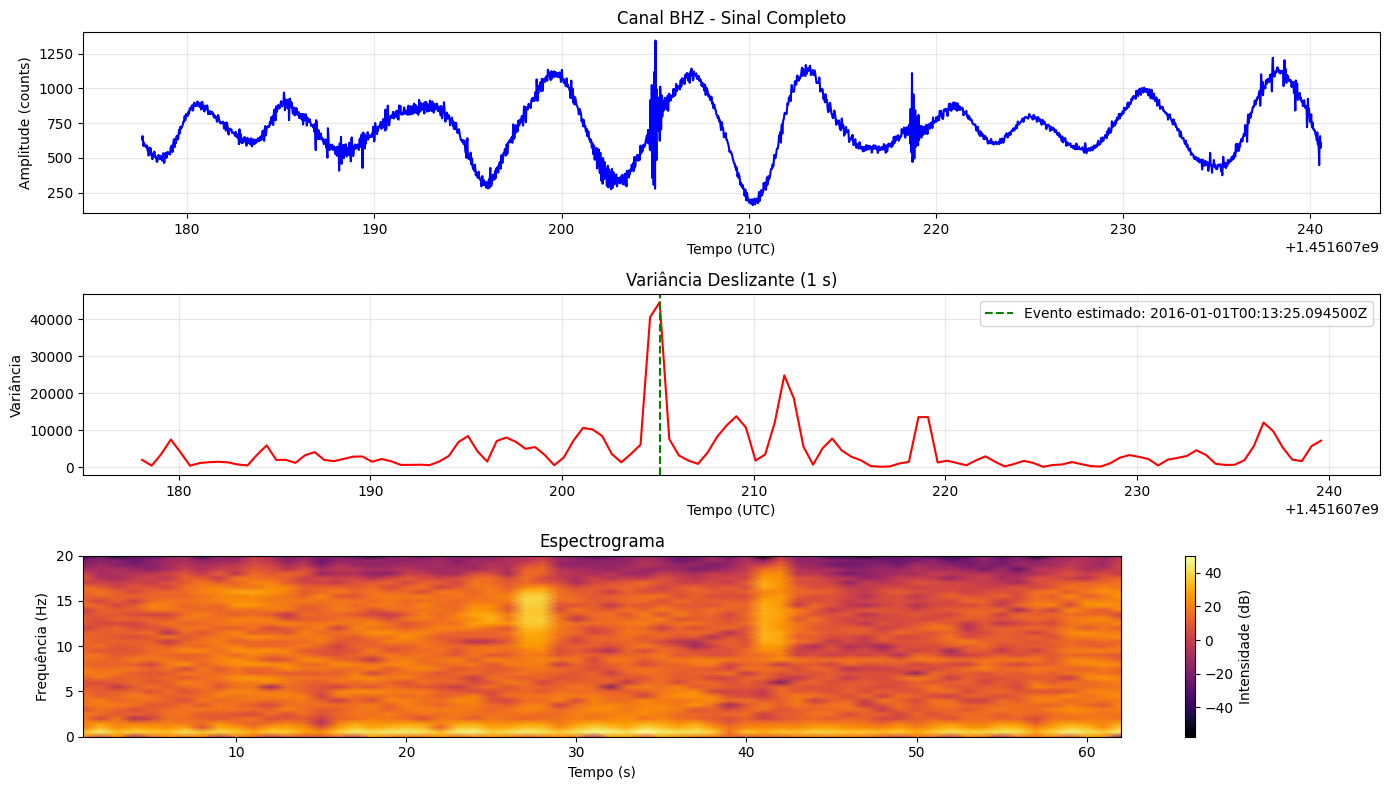

Evento estimado em t = 2016-01-01T00:13:25.094500Z UTC
Frequência mais energética no evento: 0.50 Hz
Número total de amostras: 2520
Duração total do sinal: 63.00 segundos
Figura salva em: C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts\figures\checagem_dados.png


In [4]:
from scipy import signal as scipy_signal
import os
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

if len(arquivos_ms) > 0:
    arquivo_teste = arquivos_ms[0]
    st = read(arquivo_teste)

    # Selecionando o canal alvo
    tr = None
    for trace in st:
        if trace.stats.channel.endswith(CANAL_ALVO):
            tr = trace.copy()
            break

    if tr is None:
        tr = st[0].copy()  # Usa o primeiro disponível
        print(f"⚠️ Canal {CANAL_ALVO} não encontrado, usando {tr.stats.channel} no lugar")
    else:
        print(f"✅ Canal {CANAL_ALVO} encontrado e selecionado")

    tempo = tr.times("utcdatetime")
    sinal = tr.data.astype(float)
    sr = tr.stats.sampling_rate

    # Criando os subplots
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

    # 1) Plotando o sinal completo
    axes[0].plot(tempo, sinal, color="blue")
    axes[0].set_title(f"Canal {tr.stats.channel} - Sinal Completo")
    axes[0].set_ylabel("Amplitude (counts)")
    axes[0].set_xlabel("Tempo (UTC)")
    axes[0].grid(True, alpha=0.3)

    # 2) Variância deslizante
    janela_var = int(1 * sr)  # 1 segundo
    passo = max(1, janela_var // 2)

    variancias = []
    tempos_var = []

    for i in range(0, len(sinal) - janela_var, passo):
        trecho = sinal[i:i + janela_var]
        variancias.append(np.var(trecho))
        tempos_var.append(tempo[i + janela_var // 2])  # tempo central da janela

    axes[1].plot(tempos_var, variancias, color="red")
    axes[1].set_title("Variância Deslizante (1 s)")
    axes[1].set_ylabel("Variância")
    axes[1].set_xlabel("Tempo (UTC)")
    axes[1].grid(True, alpha=0.3)

    # Detectar onde está o pico da variância
    idx_pico = np.argmax(variancias)
    t_evento_estimado = tempos_var[idx_pico]
    axes[1].axvline(
        t_evento_estimado,
        color="green",
        linestyle="--",
        label=f"Evento estimado: {t_evento_estimado}"
    )
    axes[1].legend()

    # 3) Espectrograma
    NFFT = int(2 * sr)  # janela de 2 segundos
    noverlap = NFFT // 2  # 50% de sobreposição

    f_spec, t_spec, Sxx = scipy_signal.spectrogram(
        sinal,
        fs=sr,
        nperseg=NFFT,
        noverlap=noverlap
    )

    # Evita log10(0)
    Sxx_db = 10 * np.log10(Sxx + 1e-12)

    im = axes[2].pcolormesh(
        t_spec,
        f_spec,
        Sxx_db,
        shading="gouraud",
        cmap="inferno"
    )
    axes[2].set_title("Espectrograma")
    axes[2].set_ylabel("Frequência (Hz)")
    axes[2].set_xlabel("Tempo (s)")
    fig.colorbar(im, ax=axes[2], label="Intensidade (dB)")

    plt.tight_layout()

    # Salvando a figura
    fig_path = os.path.join(PASTA_PROJETO, "figures", "checagem_dados.png")
    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Converter o tempo estimado do evento para segundos relativos ao início do traço
    tempo_evento_seg = t_evento_estimado - tr.stats.starttime

    # Encontrar o índice temporal mais próximo no espectrograma
    idx_spec = np.argmin(np.abs(t_spec - tempo_evento_seg))

    # Encontrar a frequência mais energética nesse instante
    freq_mais_energetica = f_spec[np.argmax(Sxx[:, idx_spec])]

    print(f"Evento estimado em t = {t_evento_estimado} UTC")
    print(f"Frequência mais energética no evento: {freq_mais_energetica:.2f} Hz")
    print(f"Número total de amostras: {len(sinal)}")
    print(f"Duração total do sinal: {len(sinal) / sr:.2f} segundos")
    print(f"Figura salva em: {fig_path}")
else:
    print("Nenhum arquivo MiniSEED encontrado em arquivos_ms.")

In [7]:
import os
import pandas as pd
from obspy import read
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print(f"Processando {len(arquivos_ms)} arquivos...")
print("-" * 60)

registros = []
erros = []

for i, caminho_ms in enumerate(arquivos_ms):
    try:
        st = read(caminho_ms)

        # Tentar pegar canal alvo, senão pega o primeiro
        tr = None
        for trace in st:
            if trace.stats.channel.endswith(CANAL_ALVO):
                tr = trace.copy()
                break

        if tr is None:
            tr = st[0].copy()

        sinal = tr.data.astype(float)
        sr = tr.stats.sampling_rate
        duracao = len(sinal) / sr

        # Estatísticas básicas
        var_global = np.var(sinal)

        # Variância por janela de 1s para estimar localização do evento
        janela_var = int(1 * sr)
        passo = max(1, janela_var // 2)

        variancias = []
        for j in range(0, len(sinal) - janela_var, passo):
            variancias.append(np.var(sinal[j:j + janela_var]))

        var_max = max(variancias) if variancias else 0
        var_min = min(variancias) if variancias else 0
        razao = var_max / (var_min + 1e-10)
        t_pico = np.argmax(variancias) * 0.5 if variancias else 0  # segundos

        # Tentar encontrar o XML correspondente
        rede = tr.stats.network
        estacao = tr.stats.station
        xml_encontrado = False

        for xml in arquivos_xml:
            nome_xml = os.path.basename(xml)
            if rede in nome_xml and estacao in nome_xml:
                xml_encontrado = True
                break

        registros.append({
            'arquivo': os.path.basename(caminho_ms),
            'caminho': caminho_ms,
            'rede': rede,
            'estacao': estacao,
            'canal': tr.stats.channel,
            'taxa_hz': sr,
            'n_amostras': len(sinal),
            'duracao_s': round(duracao, 1),
            'starttime': str(tr.stats.starttime),
            'var_global': round(var_global, 2),
            'var_min': round(var_min, 2),
            'var_max': round(var_max, 2),
            'razao_var': round(razao, 1),
            't_evento_est': round(t_pico, 1),
            'xml_disponivel': xml_encontrado,
            'status': 'ok'
        })

        if (i + 1) % 5 == 0 or (i + 1) == len(arquivos_ms):
            print(
                f"  [{i+1:3d}/{len(arquivos_ms)}] {os.path.basename(caminho_ms):35s} "
                f"| {duracao:5.0f}s | razão_var={razao:.0f}x "
                f"| XML={'✅' if xml_encontrado else '❌'}"
            )

    except Exception as e:
        erros.append({
            'arquivo': os.path.basename(caminho_ms),
            'erro': str(e)
        })
        print(f"  ❌ ERRO em {os.path.basename(caminho_ms)}: {e}")

# Montar DataFrame
df = pd.DataFrame(registros)

print()
print("=" * 60)
print(f"✅ Processados com sucesso : {len(registros)}")
print(f"❌ Erros                  : {len(erros)}")

Processando 31 arquivos...
------------------------------------------------------------
  [  5/31] 37509264.ms                         |    66s | razão_var=231x | XML=✅
  [ 10/31] 37509312.ms                         |    63s | razão_var=278x | XML=❌
  [ 15/31] 37509352.ms                         |    63s | razão_var=340x | XML=✅
  [ 20/31] 37509392.ms                         |    63s | razão_var=182x | XML=✅
  [ 25/31] 37509440.ms                         |    63s | razão_var=344x | XML=✅
  [ 30/31] 37509480.ms                         |    66s | razão_var=166x | XML=✅
  [ 31/31] 37509488.ms                         |    63s | razão_var=81x | XML=✅

✅ Processados com sucesso : 31
❌ Erros                  : 0


In [11]:
#Analisando o inventario

if len(df) > 0:
    print("📊 RESUMO DO SEU DATASET")
    print("=" * 60)
    print(f"Total de arquivos válidos : {len(df)}")
    print(f"Estações únicas           : {df['estacao'].nunique()}")
    print(f"Redes únicas              : {df['rede'].nunique()}")
    print(f"Taxa de amostragem        : {df['taxa_hz'].unique()} Hz")
    print(f"Duração média             : {df['duracao_s'].mean():.1f}s")
    print(f"Arquivos com XML          : {df['xml_disponivel'].sum()} / {len(df)}")
    print()
    
    # Separar eventos claros de ambíguos pela razão de variância
    # Razão alta = evento claro (energia do evento >> ruído)
    df_eventos_claros = df[df['razao_var'] > 10].copy()
    df_ambiguos       = df[(df['razao_var'] >= 2) & (df['razao_var'] <= 10)].copy()
    df_so_ruido       = df[df['razao_var'] < 2].copy()
    
    print(f"🔴 Eventos claros (razão_var > 10x) : {len(df_eventos_claros)}")
    print(f"🟡 Ambíguos (2x a 10x)             : {len(df_ambiguos)}")
    print(f"⚪ Só ruído ou evento fraco (<2x)   : {len(df_so_ruido)}")
    print()
    
    # Adicionar classificação
    df['classificacao'] = 'ruido'
    df.loc[df['razao_var'] >= 2,  'classificacao'] = 'ambiguo'
    df.loc[df['razao_var'] > 10,  'classificacao'] = 'evento_claro'
    
    print("Top 10 eventos com maior contraste (melhores para treino/teste):")
    print(df.nlargest(10, 'razao_var')[
        ['arquivo','estacao','duracao_s','razao_var','t_evento_est','xml_disponivel']
    ].to_string(index=False))
    
    # Salvar inventário
    csv_path = os.path.join(PASTA_PROJETO, "data", "inventario_dados.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n💾 Inventário salvo em: {csv_path}")


📊 RESUMO DO SEU DATASET
Total de arquivos válidos : 31
Estações únicas           : 7
Redes únicas              : 3
Taxa de amostragem        : [40.] Hz
Duração média             : 65.4s
Arquivos com XML          : 24 / 31

🔴 Eventos claros (razão_var > 10x) : 29
🟡 Ambíguos (2x a 10x)             : 2
⚪ Só ruído ou evento fraco (<2x)   : 0

Top 10 eventos com maior contraste (melhores para treino/teste):
    arquivo estacao  duracao_s  razao_var  t_evento_est  xml_disponivel
37509416.ms     BZN       63.0     2023.9          15.5            True
37509376.ms     BZN       63.0     1654.9          12.5            True
37509384.ms     BZN       66.0      517.1          16.5            True
37509336.ms     BZN       66.0      510.5          24.0            True
37509432.ms     BZN       66.0      475.2          13.5            True
37509296.ms     BZN       63.0      355.6          42.5            True
37509440.ms     BZN       63.0      344.4          44.0            True
37509352.ms     BZ

In [12]:
print("=" * 60)
print("RESUMO FINAL — PASSO 1")
print("=" * 60)

if len(df) > 0:
    n_ok  = len(df[df['xml_disponivel'] == True])
    n_ev  = len(df[df['classificacao'] == 'evento_claro'])
    
    print(f"\n📦 Dados disponíveis:")
    print(f"   Arquivos .ms válidos       : {len(df)}")
    print(f"   Com XML (podem processar)  : {n_ok}")
    print(f"   Eventos claros detectados  : {n_ev}")
    
    # Verificar se tem o suficiente
    print(f"\n📋 Checklist para o paper IEEE:")
    
    checks = [
        (len(df) >= 20,      f"≥ 20 arquivos .ms              [{len(df)} disponíveis]"),
        (n_ok >= 15,         f"≥ 15 arquivos com XML          [{n_ok} disponíveis]"),
        (n_ev >= 10,         f"≥ 10 eventos claros            [{n_ev} disponíveis]"),
    ]
    
    tudo_ok = True
    for ok, msg in checks:
        icone = "✅" if ok else "❌"
        print(f"   {icone} {msg}")
        if not ok:
            tudo_ok = False
    
    print()
    if tudo_ok:
        print("🚀 PRONTO para o Passo 2 — Pipeline limpo e correto")
        print("   Próximo: construir o pipeline.py definitivo")
    else:
        print("⚠️  Você pode precisar baixar mais dados do SCEDC.")
        print("   Mas podemos avançar com o que tem e baixar mais em paralelo.")
    
    print(f"\n💾 Inventário salvo: {os.path.join(PASTA_PROJETO, 'data', 'inventario_dados.csv')}")
    print("   Abra este arquivo para ver o mapa completo dos seus dados.")
else:
    print("❌ Nenhum dado processado. Verifique os caminhos na Célula 1.")


RESUMO FINAL — PASSO 1

📦 Dados disponíveis:
   Arquivos .ms válidos       : 31
   Com XML (podem processar)  : 24
   Eventos claros detectados  : 29

📋 Checklist para o paper IEEE:
   ✅ ≥ 20 arquivos .ms              [31 disponíveis]
   ✅ ≥ 15 arquivos com XML          [24 disponíveis]
   ✅ ≥ 10 eventos claros            [29 disponíveis]

🚀 PRONTO para o Passo 2 — Pipeline limpo e correto
   Próximo: construir o pipeline.py definitivo

💾 Inventário salvo: C:\Users\vish8\OneDrive\Documentos\TCC\Trabalho\artefacts\data\inventario_dados.csv
   Abra este arquivo para ver o mapa completo dos seus dados.


In [10]:
!pip uninstall pandas -y
!pip cache purge
!pip install pandas

Found existing installation: pandas 3.0.1
Uninstalling pandas-3.0.1:
  Successfully uninstalled pandas-3.0.1


You can safely remove it manually.


Files removed: 2918 (1387.3 MB)
Directories removed: 2376
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 8.4 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 8.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.9 MB 8.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.9 MB 8.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.7 MB/s  0:00:01
